# 📊 Step P1.1 — Exploratory Data Analysis: LANL Auth Dataset

**What is this notebook about?**  
We are going to explore the LANL (Los Alamos National Laboratory) Cyber1 authentication dataset.  
This dataset contains **over 1 billion** authentication log events collected over **58 days** from a real enterprise network.

**Why are we doing this?**  
Before building *any* ML pipeline or parser, you **must** understand your data:  
- What columns exist? What do they mean?  
- How many events, users, and hosts are there?  
- What's the distribution of event types?  
- Where are the red team (attack) events hiding?  

**What you will learn:**  
1. How to load massive CSV files using **chunked reading** (you can't fit 68 GB into RAM!)  
2. How to use `pandas` for basic data exploration  
3. How to use `matplotlib` and `seaborn` for visualization  
4. How to think about data before building models  

---

## 🧱 Lesson 1: Imports — Loading Our Toolbox

### Concept
Every Python program starts with **imports** — these are pre-built libraries that give us superpowers:  

| Library | What It Does | Analogy |
|---------|-------------|--------|
| `pandas` | Data manipulation (tables, filtering, grouping) | Excel on steroids |
| `matplotlib` | Basic plotting (charts, graphs) | A drawing canvas |
| `seaborn` | Beautiful statistical plots (built on matplotlib) | A designer on top of the canvas |
| `os` | Interact with the file system (paths, file sizes) | File explorer |
| `collections` | Specialized data structures (counters, etc.) | A counting machine |

### Why do we `import X as Y`?
Writing `pandas` every time is tedious. `pd` is the universal shorthand the entire Python community uses.  
Same with `numpy as np`, `matplotlib.pyplot as plt`, `seaborn as sns`.  
**These are conventions — memorize them. You'll see them in every data science project.**

---

### ✏️ Exercise 1: Fill in the missing imports

Look at the code below. Some imports are missing — fill in the blanks (`____`).

In [1]:
# ============================================================
# EXERCISE 1: Fill in the blanks for each import
# ============================================================

# Blank 1: Import pandas with the standard alias
import pandas as pd 

# Blank 2: Import the pyplot module from matplotlib with standard alias
import matplotlib.pyplot as plt

# Blank 3: Import seaborn with the standard alias
import seaborn as sns 

# These are standard library imports (no alias needed)
import os
from collections import Counter

# This line makes plots appear inside the notebook (not in a popup window)
%matplotlib inline

# Set a clean visual style for our plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)     # Default plot size
plt.rcParams['font.size'] = 12                # Default font size

### 🔑 Hints for Exercise 1

<details>
<summary>Click to reveal hints</summary>

- Blank 1: What 2-letter abbreviation does everyone use for pandas?  
- Blank 2: The plotting module inside `matplotlib` is called `p_______`  
- Blank 3: What 3-letter abbreviation does everyone use for seaborn?  

</details>

**⏸️ STOP — Try filling in the blanks before scrolling down!**

---

### ✅ Solution for Exercise 1

<details>
<summary>Click to reveal solution</summary>

```python
import pandas as pd           # Blank 1: pd
import matplotlib.pyplot as plt  # Blank 2: pyplot
import seaborn as sns          # Blank 3: sns
```

**Line-by-line:**  
- `pd` → universal alias for pandas. Every tutorial, StackOverflow answer, and production codebase uses this.  
- `pyplot` → matplotlib has many submodules. `pyplot` is the one with `plot()`, `bar()`, `show()`, etc.  
- `sns` → stands for "Samuel Norman Seaborn" (yes, a West Wing character — the library creator was a fan).  

</details>

In [2]:
# ============================================================
# CORRECT VERSION — Run this cell to load all imports
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('✅ All imports loaded successfully!')

✅ All imports loaded successfully!


---

## 🧱 Lesson 2: Understanding the Dataset Schema

### Concept: What does the raw data look like?

The LANL auth.txt file is a **CSV** (Comma-Separated Values) file with **no header row**.  
Each line represents one authentication event. Here's what each column means:

| Position | Column Name | What It Represents | Example |
|----------|------------|--------------------|---------|
| 0 | `time` | Timestamp in seconds since data collection started | `1` |
| 1 | `src_user` | The user who initiated the action (`user@domain`) | `U101@DOM1` |
| 2 | `dst_user` | The user being authenticated to (`user@domain`) | `SYSTEM@C1020` |
| 3 | `src_computer` | The computer the action came FROM | `C1020` |
| 4 | `dst_computer` | The computer the action targets | `C586` |
| 5 | `auth_type` | Authentication protocol used | `Kerberos`, `NTLM`, `Negotiate`, `?` |
| 6 | `logon_type` | How the logon happened | `Network`, `Interactive`, `Service`, etc. |
| 7 | `auth_orientation` | Direction of the auth event | `LogOn`, `LogOff`, `TGS`, `TGT`, `AuthMap` |
| 8 | `success` | Did it succeed? | `Success`, `Fail` |

### Why no header?
Many large-scale datasets from research labs skip headers to save space and simplify processing.  
When there's no header, **you** must tell pandas what the column names are.

### The size problem 🚨
This file is **68 GB** with **1,051,430,459 lines** (over 1 billion events).  
A typical laptop has 8-16 GB of RAM. You **cannot** do `pd.read_csv('auth.txt')` — it would crash.  

**Solution:** We'll use `nrows` to load a small sample first, then use **chunked reading** for full-dataset stats.

---

### ✅ Setup Note (for your environment)

You already have decompressed LANL files locally:
- `data/lanl/auth.txt`
- `data/lanl/redteam.txt`

So you can skip downloading/decompressing and go straight to EDA.

### ✏️ Exercise 2: Define the file path and column names

Your task:
1. Set the `DATA_PATH` variable to point to your `auth.txt` file  
2. Create a list of column names matching the schema table above  
3. Print the file size in GB

In [ ]:
# ============================================================
# EXERCISE 2: Fill in the blanks
# ============================================================

# Blank 1: Complete the file path to auth.txt
# Hint: The file is inside your project's data/lanl/ folder
DATA_PATH = r'data/lanl/auth.txt'

# Blank 2: Define the column names in the correct order
# Refer to the schema table above — there are 9 columns
COLUMN_NAMES = [
    '____',        # position 0: timestamp
    '____',        # position 1: source user
    '____',        # position 2: destination user  
    '____',        # position 3: source computer
    '____',        # position 4: destination computer
    '____',        # position 5: authentication type
    '____',        # position 6: logon type
    '____',        # position 7: authentication orientation
    '____'         # position 8: success or failure
]

# Blank 3: Get the file size in bytes using os.path, then convert to GB
# Hint: divide by (1024 ** 3) to convert bytes → GB
file_size_bytes = os.path.____(DATA_PATH)
file_size_gb = file_size_bytes / ____

print(f'📁 Data file: {DATA_PATH}')
print(f'📊 File size: {file_size_gb:.2f} GB')
print(f'📋 Column names: {COLUMN_NAMES}')

### 🔑 Hints for Exercise 2

<details>
<summary>Click to reveal hints</summary>

- Blank 1: The path should end with `...\\data\\lanl\\auth.txt`  
- Blank 2: Use the names from the schema table: `time`, `src_user`, `dst_user`, etc.  
- Blank 3: `os.path.getsize()` returns file size in bytes. 1 GB = 1024³ bytes  

</details>

**⏸️ STOP — Fill in the blanks above!**

---

### ✅ Solution for Exercise 2

<details>
<summary>Click to reveal solution</summary>

```python
DATA_PATH = r'c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\data\lanl\auth.txt'

COLUMN_NAMES = [
    'time',             # position 0
    'src_user',         # position 1
    'dst_user',         # position 2
    'src_computer',     # position 3
    'dst_computer',     # position 4
    'auth_type',        # position 5
    'logon_type',       # position 6
    'auth_orientation', # position 7
    'success'           # position 8
]

file_size_bytes = os.path.getsize(DATA_PATH)
file_size_gb = file_size_bytes / (1024 ** 3)
```

**Line-by-line:**  
- `r'...'` — the `r` prefix means "raw string". It tells Python NOT to interpret backslashes as escape characters. Without it, `\n` would become a newline, `\t` would become a tab, etc.  
- `os.path.getsize()` — returns file size in bytes.  
- `(1024 ** 3)` — 1 KB = 1024 bytes, 1 MB = 1024², 1 GB = 1024³.  

</details>

In [3]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

DATA_PATH = os.path.join(
    os.path.dirname(os.getcwd()),   # go up one level from notebooks/
    'data', 'lanl', 'auth.txt'
)

# Fallback to absolute path if relative doesn't work
if not os.path.exists(DATA_PATH):
    DATA_PATH = r'c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\data\lanl\auth.txt'

REDTEAM_PATH = os.path.join(os.path.dirname(DATA_PATH), 'redteam.txt')

COLUMN_NAMES = [
    'time',             # Timestamp (seconds from start of collection)
    'src_user',         # Source user@domain
    'dst_user',         # Destination user@domain
    'src_computer',     # Source computer
    'dst_computer',     # Destination computer
    'auth_type',        # Authentication type (Kerberos, NTLM, etc.)
    'logon_type',       # Logon type (Network, Interactive, etc.)
    'auth_orientation', # LogOn, LogOff, TGS, TGT, AuthMap
    'success'           # Success or Fail
]

file_size_gb = os.path.getsize(DATA_PATH) / (1024 ** 3)
TOTAL_LINES = 1_051_430_459  # Pre-counted (took ~12 min to count!)

print(f'📁 Data file: {DATA_PATH}')
print(f'📊 File size: {file_size_gb:.2f} GB')
print(f'📋 Columns:   {COLUMN_NAMES}')
print(f'📝 Total rows: {TOTAL_LINES:,}')

if os.path.exists(REDTEAM_PATH):
    print(f'🔴 Red team file found: {REDTEAM_PATH}')
else:
    print(f'⚠️ Red team file not found yet: {REDTEAM_PATH}')
    print('   If already decompressed, place redteam.txt in data/lanl/')

print(f'\n✅ Dataset configuration loaded!')

📁 Data file: c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\data\lanl\auth.txt
📊 File size: 68.37 GB
📋 Columns:   ['time', 'src_user', 'dst_user', 'src_computer', 'dst_computer', 'auth_type', 'logon_type', 'auth_orientation', 'success']
📝 Total rows: 1,051,430,459
🔴 Red team file found: c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\data\lanl\redteam.txt

✅ Dataset configuration loaded!


---

## 🧱 Lesson 3: Loading a Sample — Your First `read_csv`

### Concept: Why load a sample first?

When you have a 68 GB file, you **never** start by loading all of it. Instead:

1. **Load a tiny sample** (e.g., first 100,000 rows) → Understand structure  
2. **Load a medium sample** (e.g., 5 million rows) → Explore patterns  
3. **Process the full file in chunks** → Compute full-dataset statistics  

### Key `pd.read_csv()` parameters for our case:

| Parameter | What It Does | Our Value |
|-----------|-------------|----------|
| `filepath` | Path to the file | `DATA_PATH` |
| `header=None` | Tells pandas there's NO header row | `None` |
| `names=` | Provide our own column names | `COLUMN_NAMES` |
| `nrows=` | Only read this many rows | `100_000` |

---

### ✏️ Exercise 3: Load the first 100,000 rows

In [ ]:
# ============================================================
# EXERCISE 3: Load a sample of the data
# ============================================================

# Blank 1: Use pd.read_csv with the right parameters
# Remember: no header in the file, we provide our own column names,
# and we only want the first 100,000 rows
df_sample = pd.read_csv(                   
    DATA_PATH,
    header=None,           # Blank 2: What value means 'no header'?
    names=COLUMN_NAMES,    # Blank 3: Our list of column names
    nrows=100000           # Blank 4: How many rows to read?
)

# Check the result
print(f'Shape: {df_sample.shape}')       # (rows, columns)
print(f'Columns: {list(df_sample.columns)}')
print(f'\nFirst 5 rows:')
df_sample.head()

### 🔑 Hints for Exercise 3

<details>
<summary>Click to reveal hints</summary>

- Blank 1: The function to read CSV files is `read_csv`  
- Blank 2: In Python, `None` means "nothing" — no header exists  
- Blank 3: We defined this earlier — it's `COLUMN_NAMES`  
- Blank 4: We want 100,000 rows. Python lets you write `100_000` for readability (underscores are ignored)  

</details>

**⏸️ STOP — Fill in the blanks!**

---

### ✅ Solution for Exercise 3

<details>
<summary>Click to reveal solution</summary>

```python
df_sample = pd.read_csv(
    DATA_PATH,
    header=None,           # No header row in the file
    names=COLUMN_NAMES,    # Our custom column names
    nrows=100_000          # Only load first 100K rows
)
```

**Why `header=None`?**  
By default, pandas assumes the first row is a header. Since auth.txt starts directly with data, we need to tell pandas "there is no header — treat every row as data."

**Why `nrows=100_000`?**  
100K rows is large enough to see patterns but small enough to fit in memory instantly.  
At ~70 bytes per row, 100K rows = ~7 MB. Totally fine.

</details>

In [4]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

df_sample = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLUMN_NAMES,
    nrows=100_000
)

print(f'✅ Loaded {len(df_sample):,} rows × {len(df_sample.columns)} columns')
print(f'\n📊 Shape: {df_sample.shape}')
print(f'\n📋 Data types:')
print(df_sample.dtypes)
print(f'\n📝 First 5 rows:')
df_sample.head()

✅ Loaded 100,000 rows × 9 columns

📊 Shape: (100000, 9)

📋 Data types:
time                 int64
src_user            object
dst_user            object
src_computer        object
dst_computer        object
auth_type           object
logon_type          object
auth_orientation    object
success             object
dtype: object

📝 First 5 rows:


,time,src_user,dst_user,src_computer,dst_computer,auth_type,logon_type,auth_orientation,success
0,1,ANONYMOUS LOGON@C586,ANONYMOUS LOGON@C586,C1250,C586,NTLM,Network,LogOn,Success
1,1,ANONYMOUS LOGON@C586,ANONYMOUS LOGON@C586,C586,C586,?,Network,LogOff,Success
2,1,C101$@DOM1,C101$@DOM1,C988,C988,?,Network,LogOff,Success
3,1,C1020$@DOM1,SYSTEM@C1020,C1020,C1020,Negotiate,Service,LogOn,Success
4,1,C1021$@DOM1,C1021$@DOM1,C1021,C625,Kerberos,Network,LogOn,Success


---

## 🧱 Lesson 4: Basic Data Inspection

### Concept: The "first 5 questions" for any dataset

Every time you get a new dataset, always ask these questions (in this order):

1. **What shape is it?** → `.shape` — how many rows and columns?  
2. **What types are the columns?** → `.dtypes` — are numbers stored as numbers?  
3. **Are there missing values?** → `.isnull().sum()` — any blank cells?  
4. **What do the numbers look like?** → `.describe()` — min, max, mean, etc.  
5. **What are the unique categories?** → `.nunique()` and `.value_counts()` — what values appear?  

---

### ✏️ Exercise 4: Answer the 5 questions

In [ ]:
# ============================================================
# EXERCISE 4: Fill in the blanks to inspect the data
# ============================================================

# Question 1: What shape is the data?
# Blank 1: What attribute gives you (rows, columns)?
print('Q1 — Shape:', df_sample.shape)

print('\n' + '='*50)

# Question 2: What data types are the columns?
# Blank 2: What attribute shows column data types?
print('Q2 — Data types:')
print(df_sample.dtypes)

print('\n' + '='*50)

# Question 3: Are there missing values?
# Blank 3: Chain two methods: first checks for null, second sums them
print('Q3 — Missing values per column:')
print(df_sample.isnull().sum())

print('\n' + '='*50)

# Question 4: What do the numeric columns look like?
# Blank 4: What method gives you min, max, mean, std, etc.?
print('Q4 — Numeric summary:')
print(df_sample.describe())

print('\n' + '='*50)

# Question 5: How many unique values in each column?
# Blank 5: What method counts unique values per column?
print('Q5 — Unique values per column:')
print(df_sample.nunique())

### 🔑 Hints for Exercise 4

<details>
<summary>Click to reveal hints</summary>

- Blank 1: `shape` (no parentheses — it's a property, not a method)  
- Blank 2: `dtypes` (no parentheses)  
- Blank 3: `.isnull()` returns True/False for each cell, `.sum()` counts the Trues  
- Blank 4: `.describe()` — gives statistical summary of numeric columns  
- Blank 5: `.nunique()` — counts distinct values per column  

</details>

**⏸️ STOP — Fill in the blanks!**

---

### ✅ Solution for Exercise 4

<details>
<summary>Click to reveal solution</summary>

```python
print('Q1 — Shape:', df_sample.shape)
print('Q2 — Data types:'); print(df_sample.dtypes)
print('Q3 — Missing values:'); print(df_sample.isnull().sum())
print('Q4 — Numeric summary:'); print(df_sample.describe())
print('Q5 — Unique values:'); print(df_sample.nunique())
```

**Key observations you should notice:**   
- `time` is an integer (seconds) — the max value tells us how far into the 58 days this sample reaches  
- `auth_type` might contain `?` — that's a legitimate value meaning "unknown"  
- `success` should be mostly "Success" with some "Fail" values  
- The unique counts tell us how many users and computers exist in just this sample  

</details>

In [5]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

print('='*60)
print('Q1 — SHAPE')
print('='*60)
print(f'Rows: {df_sample.shape[0]:,}  |  Columns: {df_sample.shape[1]}')

print(f'\n{"="*60}')
print('Q2 — DATA TYPES')
print('='*60)
print(df_sample.dtypes)

print(f'\n{"="*60}')
print('Q3 — MISSING VALUES')
print('='*60)
missing = df_sample.isnull().sum()
print(missing)
print(f'\n💡 Total missing cells: {missing.sum()}')

print(f'\n{"="*60}')
print('Q4 — NUMERIC SUMMARY (time column)')
print('='*60)
print(df_sample['time'].describe())

print(f'\n{"="*60}')
print('Q5 — UNIQUE VALUES PER COLUMN')
print('='*60)
print(df_sample.nunique())

Q1 — SHAPE
Rows: 100,000  |  Columns: 9

Q2 — DATA TYPES
time                 int64
src_user            object
dst_user            object
src_computer        object
dst_computer        object
auth_type           object
logon_type          object
auth_orientation    object
success             object
dtype: object

Q3 — MISSING VALUES
time                0
src_user            0
dst_user            0
src_computer        0
dst_computer        0
auth_type           0
logon_type          0
auth_orientation    0
success             0
dtype: int64

💡 Total missing cells: 0

Q4 — NUMERIC SUMMARY (time column)
count    100000.000000
mean        479.022580
std         276.700237
min           1.000000
25%         245.000000
50%         474.000000
75%         714.000000
max         964.000000
Name: time, dtype: float64

Q5 — UNIQUE VALUES PER COLUMN
time                 964
src_user            4923
dst_user            6299
src_computer        3971
dst_computer        2401
auth_type              8


---

## 🧱 Lesson 5: Exploring Categorical Columns with `value_counts()`

### Concept: What is `value_counts()`?

For **categorical** columns (columns with text/labels, not numbers), we want to know:  
- What values appear?  
- How often does each value occur?  
- Which value is most common?  

`df['column'].value_counts()` does exactly this — it counts occurrences of each unique value, sorted from most to least common.

For the LANL dataset, the important categorical columns are:  
- `auth_type` — Kerberos, NTLM, Negotiate, ?  
- `logon_type` — Network, Interactive, Service, etc.  
- `auth_orientation` — LogOn, LogOff, TGS, TGT, AuthMap  
- `success` — Success, Fail  

---

### ✏️ Exercise 5: Explore the categorical columns

In [ ]:
# ============================================================
# EXERCISE 5: Fill in the blanks
# ============================================================

categorical_cols = ['auth_type', 'logon_type', 'auth_orientation', 'success']

for col in categorical_cols:
    print(f'\n{"="*50}')
    print(f'📊 {col.upper()}')
    print('='*50)
    
    # Blank 1: Get the value counts for this column
    counts = df_sample[col].value_counts()
    print(counts)
    
    # Blank 2: Also show as percentages (normalize=True gives proportions)
    pcts = df_sample[col].value_counts(normalize=True)
    print(f'\nPercentages:')
    for value, pct in pcts.items():
        print(f'  {value}: {pct*100:.1f}%')

### 🔑 Hints for Exercise 5

<details>
<summary>Click to reveal hints</summary>

- Blank 1: Use `col` (the loop variable) to index the column, then call `.value_counts()`  
- Blank 2: `value_counts(normalize=True)` returns proportions (0.0 to 1.0) instead of raw counts  

</details>

**⏸️ STOP — Try it!**

---

### ✅ Solution for Exercise 5

<details>
<summary>Click to reveal solution</summary>

```python
counts = df_sample[col].value_counts()
pcts = df_sample[col].value_counts(normalize=True)
```

**What to notice in the output:**  
- `auth_type`: `?` is likely the most common — this means "unknown" protocol  
- `logon_type`: `Network` dominates — most auth events are network-based  
- `auth_orientation`: `LogOn` vs `LogOff` ratio tells us about session behavior  
- `success`: Overwhelming majority is `Success` — failures are interesting anomalies  

</details>

In [6]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

categorical_cols = ['auth_type', 'logon_type', 'auth_orientation', 'success']

for col in categorical_cols:
    print(f'\n{"="*55}')
    print(f'📊 {col.upper()}')
    print('='*55)
    
    counts = df_sample[col].value_counts()
    pcts = df_sample[col].value_counts(normalize=True)
    
    for value in counts.index:
        bar = '█' * int(pcts[value] * 40)  # Visual bar
        print(f'  {value:15s} {counts[value]:>8,}  ({pcts[value]*100:5.1f}%)  {bar}')


📊 AUTH_TYPE
  ?                 57,489  ( 57.5%)  ██████████████████████
  Kerberos          35,540  ( 35.5%)  ██████████████
  NTLM               4,065  (  4.1%)  █
  Negotiate          2,827  (  2.8%)  █
  MICROSOFT_AUTHENTICATION_PACKAGE_V1_0       67  (  0.1%)  
  MICROSOFT_AUTHENTICATION_PACKAG        6  (  0.0%)  
  MICROSOFT_AUTHENTICATION_PACKAGE        5  (  0.0%)  
  MICROSOFT_AUTHENTICATION_PAC        1  (  0.0%)  

📊 LOGON_TYPE
  Network           81,515  ( 81.5%)  ████████████████████████████████
  ?                 15,108  ( 15.1%)  ██████
  Service            2,241  (  2.2%)  
  Interactive          529  (  0.5%)  
  Batch                491  (  0.5%)  
  NetworkCleartext       88  (  0.1%)  
  NewCredentials        22  (  0.0%)  
  Unlock                 6  (  0.0%)  

📊 AUTH_ORIENTATION
  LogOn             42,513  ( 42.5%)  █████████████████
  LogOff            42,381  ( 42.4%)  ████████████████
  TGS                9,657  (  9.7%)  ███
  TGT                4,439  (  

---

## 🧱 Lesson 5.5: Top 20 "EventID-Equivalent" Patterns

### Concept: LANL auth data has no native EventID column

In many SIEM datasets, you analyze the top 20 EventIDs. The LANL `auth.txt` dataset does not include a Windows `EventID` field, so we build an **event signature** instead.

We'll combine four fields into one signature:
- `auth_type`
- `logon_type`
- `auth_orientation`
- `success`

This gives us an EventID-equivalent frequency view while staying faithful to the LANL schema.

---

### ✏️ Mini Exercise: Build and plot the top 20 event signatures

Fill in the blanks in the next cell, then compare the output with the discussion above.

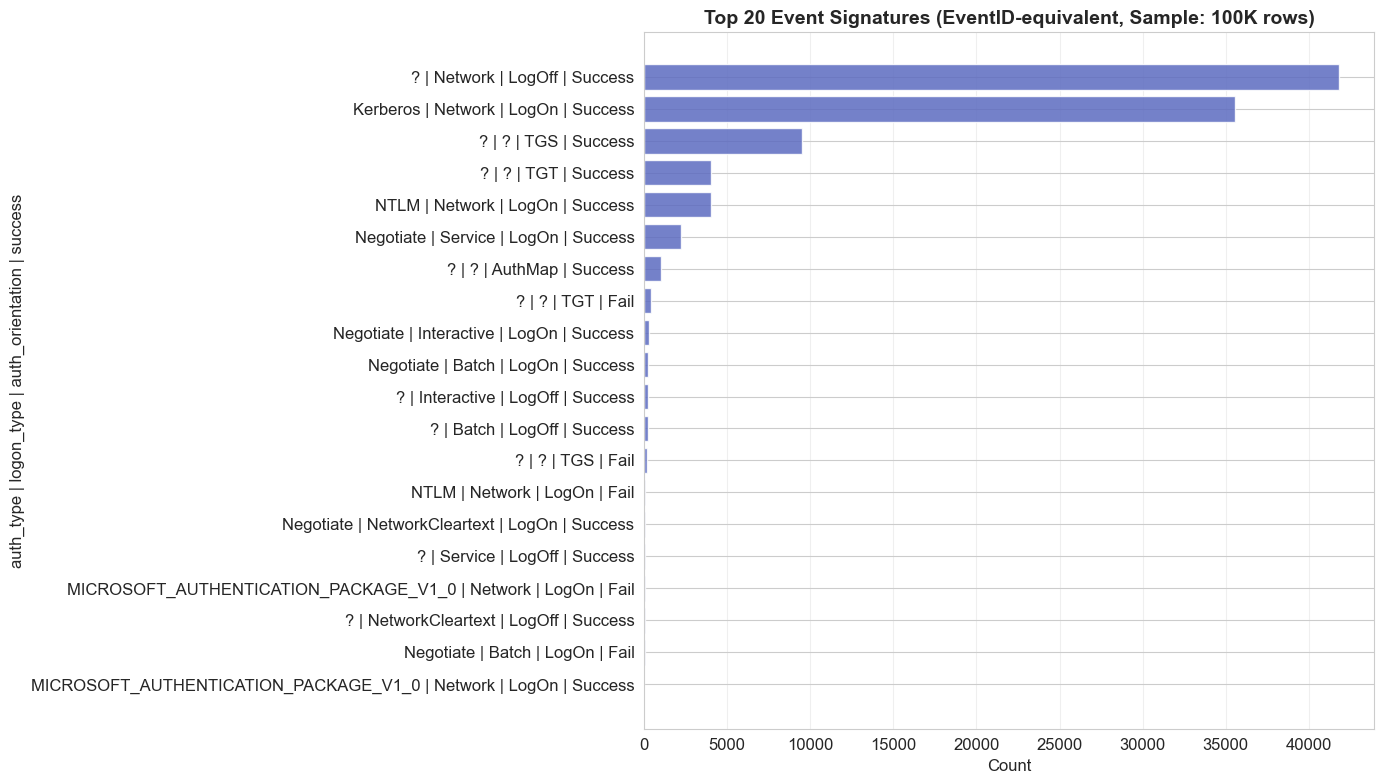

✅ In LANL auth logs, event_signature is the EventID-equivalent feature.


In [7]:
# ============================================================
# MINI EXERCISE: EventID-equivalent top 20 signatures
# ============================================================

sig_cols = ['auth_type', 'logon_type', 'auth_orientation', 'success']

# Blank 1: Build a combined event signature string using the four columns
df_sample['event_signature'] = (
    df_sample['auth_type'].astype(str) + ' | ' +
    df_sample['logon_type'].astype(str) + ' | ' +
    df_sample['auth_orientation'].astype(str) + ' | ' +
    df_sample['success'].astype(str)
)

# Blank 2: Count the top 20 signatures
top_event_signatures = df_sample['event_signature'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))

# Blank 3: Plot horizontal bars
ax.barh(
    top_event_signatures.index[::-1],
    top_event_signatures.values[::-1],
    color='#5C6BC0',
    alpha=0.85
 )

ax.set_title('Top 20 Event Signatures (EventID-equivalent, Sample: 100K rows)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('auth_type | logon_type | auth_orientation | success')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ In LANL auth logs, event_signature is the EventID-equivalent feature.')

---

## 🧱 Lesson 6: Visualization — Event Type Distribution

### Concept: Why visualize?

Numbers tell you facts. Charts tell you **stories**.  

A bar chart of event types instantly shows:
- Which authentication types dominate  
- How skewed the distribution is  
- Whether rare events even show up  

We'll create **4 subplots** — one for each categorical column.

### Key matplotlib concepts:
- `fig, axes = plt.subplots(2, 2)` — creates a 2×2 grid of plots  
- `axes[0, 0]` — the top-left subplot  
- `ax.bar()` — draws a bar chart on a specific subplot  
- `ax.set_title()` — sets the title  

---

### ✏️ Exercise 6: Create a 2×2 subplot grid of bar charts

In [ ]:
# ============================================================
# EXERCISE 6: Fill in the blanks
# ============================================================

# Blank 1: Create a figure with a 2x2 grid of subplots
# Hint: plt.subplots(rows, cols, figsize=(width, height))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

categorical_cols = ['auth_type', 'logon_type', 'auth_orientation', 'success']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for idx, col in enumerate(categorical_cols):
    # Blank 2: Calculate row and column position in the 2x2 grid
    # Hint: row = idx // 2 (integer division), col_pos = idx % 2 (remainder)
    row = idx // 2
    col_pos = idx % 2
    ax = axes[row, col_pos]
    
    # Blank 3: Get value counts for this column
    counts = df_sample[col].value_counts()
    
    # Blank 4: Create a bar chart on this subplot
    ax.bar(counts.index, counts.values, color=colors[idx], alpha=0.8)
    ax.set_title(f'{col}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Event Type Distributions (Sample: 100K rows)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔑 Hints for Exercise 6

<details>
<summary>Click to reveal hints</summary>

- Blank 1: `plt.subplots(2, 2, ...)` — 2 rows, 2 columns  
- Blank 2: For a 2-column grid: `idx // 2` gives the row, `idx % 2` gives the column  
- Blank 3: `.value_counts()` — same method from Lesson 5  
- Blank 4: `.bar()` creates a bar chart  

</details>

**⏸️ STOP — Try it!**

---

### ✅ Solution for Exercise 6

<details>
<summary>Click to reveal solution</summary>

```python
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
row = idx // 2
col_pos = idx % 2
counts = df_sample[col].value_counts()
ax.bar(counts.index, counts.values, ...)
```

**Why `//` and `%`?**  
- `//` is **integer division** (floor). `3 // 2 = 1`, `2 // 2 = 1`, `0 // 2 = 0`  
- `%` is **modulo** (remainder). `3 % 2 = 1`, `2 % 2 = 0`, `0 % 2 = 0`  
- Together they convert a flat index (0,1,2,3) into 2D grid coordinates: (0,0), (0,1), (1,0), (1,1)  

</details>

C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\663812483.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


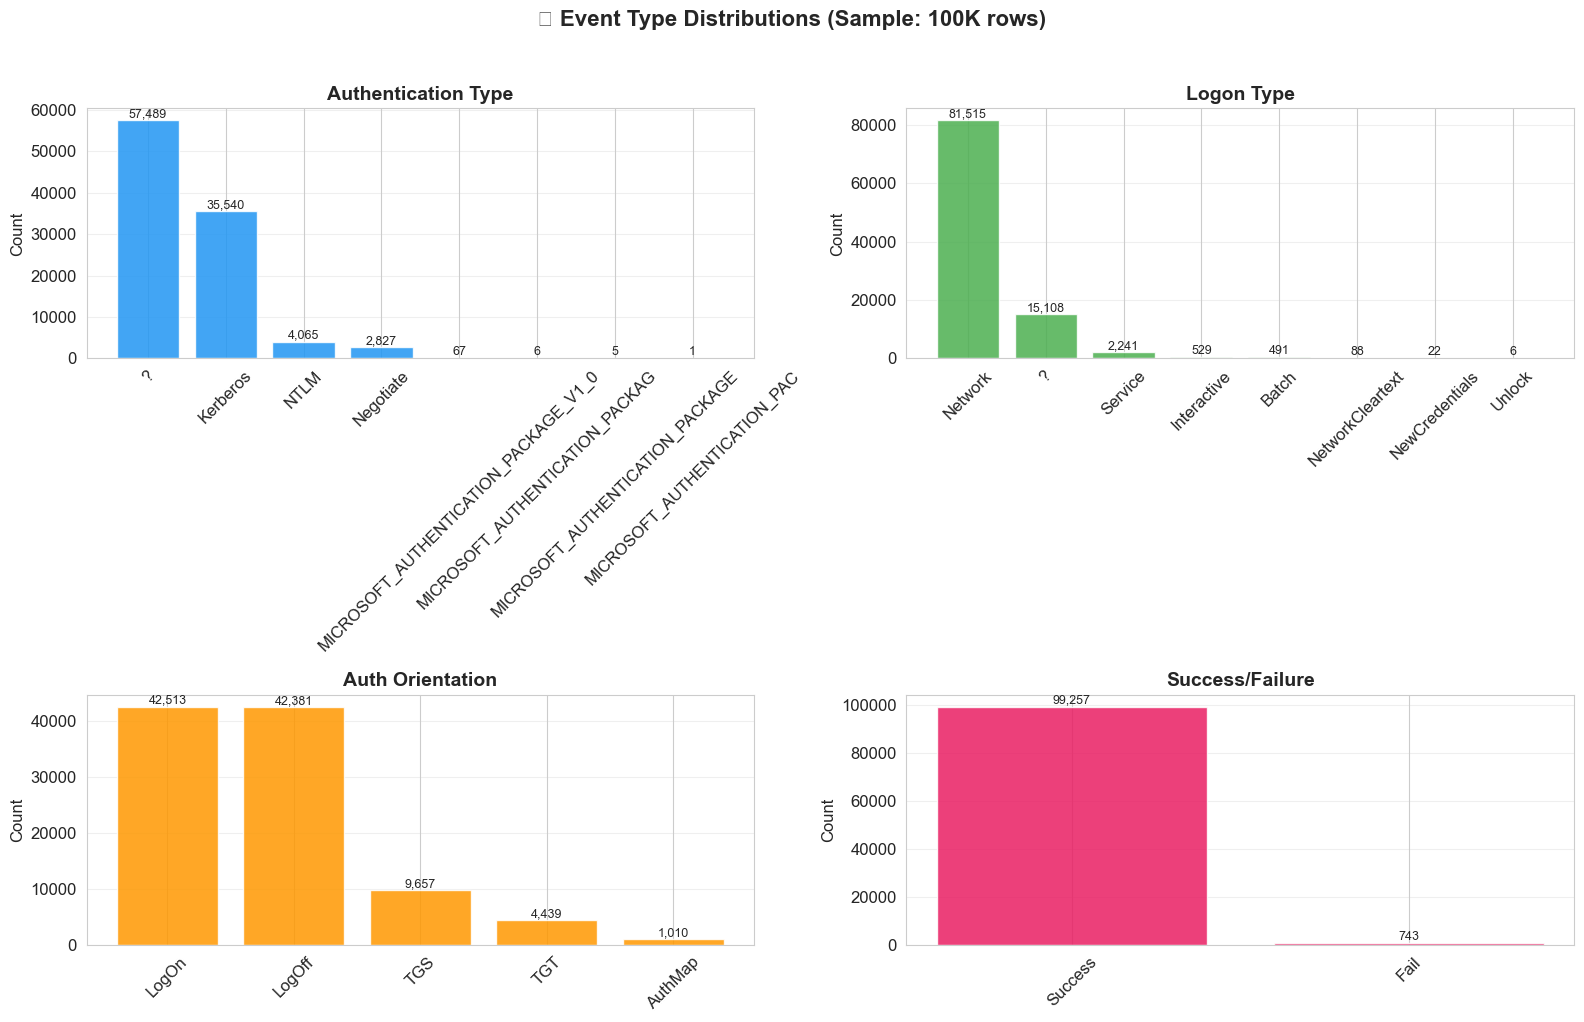

In [8]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

categorical_cols = ['auth_type', 'logon_type', 'auth_orientation', 'success']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
titles = ['Authentication Type', 'Logon Type', 'Auth Orientation', 'Success/Failure']

for idx, col in enumerate(categorical_cols):
    row = idx // 2
    col_pos = idx % 2
    ax = axes[row, col_pos]
    
    counts = df_sample[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors[idx], alpha=0.85, edgecolor='white')
    
    # Add count labels on top of each bar
    for bar_item in bars:
        height = bar_item.get_height()
        ax.text(bar_item.get_x() + bar_item.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(titles[idx], fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('📊 Event Type Distributions (Sample: 100K rows)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 🧱 Lesson 7: Top Users and Hosts Analysis

### Concept: Who are the busiest entities?

In security analytics, knowing which **users** and **computers** generate the most events is critical:  
- **Machine accounts** (like `C1020$@DOM1`) generate tons of automated logon/logoff pairs  
- **SYSTEM** and **ANONYMOUS LOGON** are special built-in accounts  
- **Real users** (like `U101@DOM1`) are the ones we care about for anomaly detection  

Let's find the top 20 source users and the top 20 computers.

---

### ✏️ Exercise 7: Find and plot the top 20 users and hosts

In [ ]:
# ============================================================
# EXERCISE 7: Fill in the blanks
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Top 20 Source Users ---
# Blank 1: Get value counts for 'src_user' column, then take top 20
# Hint: .value_counts() returns all counts, .head(20) takes the first 20
top_users = df_sample['src_user'].value_counts().head(20)

# Blank 2: Create a horizontal bar chart (barh = bar horizontal)
ax1.barh(top_users.index, top_users.values, color='#2196F3', alpha=0.85)
ax1.set_title('Top 20 Source Users', fontsize=14, fontweight='bold')
ax1.set_xlabel('Event Count')
ax1.invert_yaxis()  # Put highest at the top

# --- Top 20 Destination Computers ---
# Blank 3: Same thing but for 'dst_computer' column
top_hosts = df_sample['dst_computer'].value_counts().head(20)

ax2.barh(top_hosts.index, top_hosts.values, color='#FF9800', alpha=0.85)
ax2.set_title('Top 20 Destination Computers', fontsize=14, fontweight='bold')
ax2.set_xlabel('Event Count')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### 🔑 Hints for Exercise 7

<details>
<summary>Click to reveal hints</summary>

- Blank 1: Column is `src_user`, method is `value_counts()`, and take `.head(20)`  
- Blank 2: `barh` = horizontal bar chart (better for long labels)  
- Blank 3: Column is `dst_computer`, same pattern as above  

</details>

**⏸️ STOP — Try it!**

---

### ✅ Solution for Exercise 7

<details>
<summary>Click to reveal solution</summary>

```python
top_users = df_sample['src_user'].value_counts().head(20)
ax1.barh(top_users.index, top_users.values, ...)

top_hosts = df_sample['dst_computer'].value_counts().head(20)
ax2.barh(top_hosts.index, top_hosts.values, ...)
```

**What to observe:**  
- Machine accounts (`C????$@DOM1`) will dominate — they authenticate constantly  
- `ANONYMOUS LOGON` is Windows network browsing traffic  
- Real human users start with `U` (e.g., `U101@DOM1`)  
- A few destination computers will receive far more connections than others — these are likely **servers** (Domain Controllers, file servers, etc.)  

</details>

C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\2792934030.py:31: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\2792934030.py:31: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


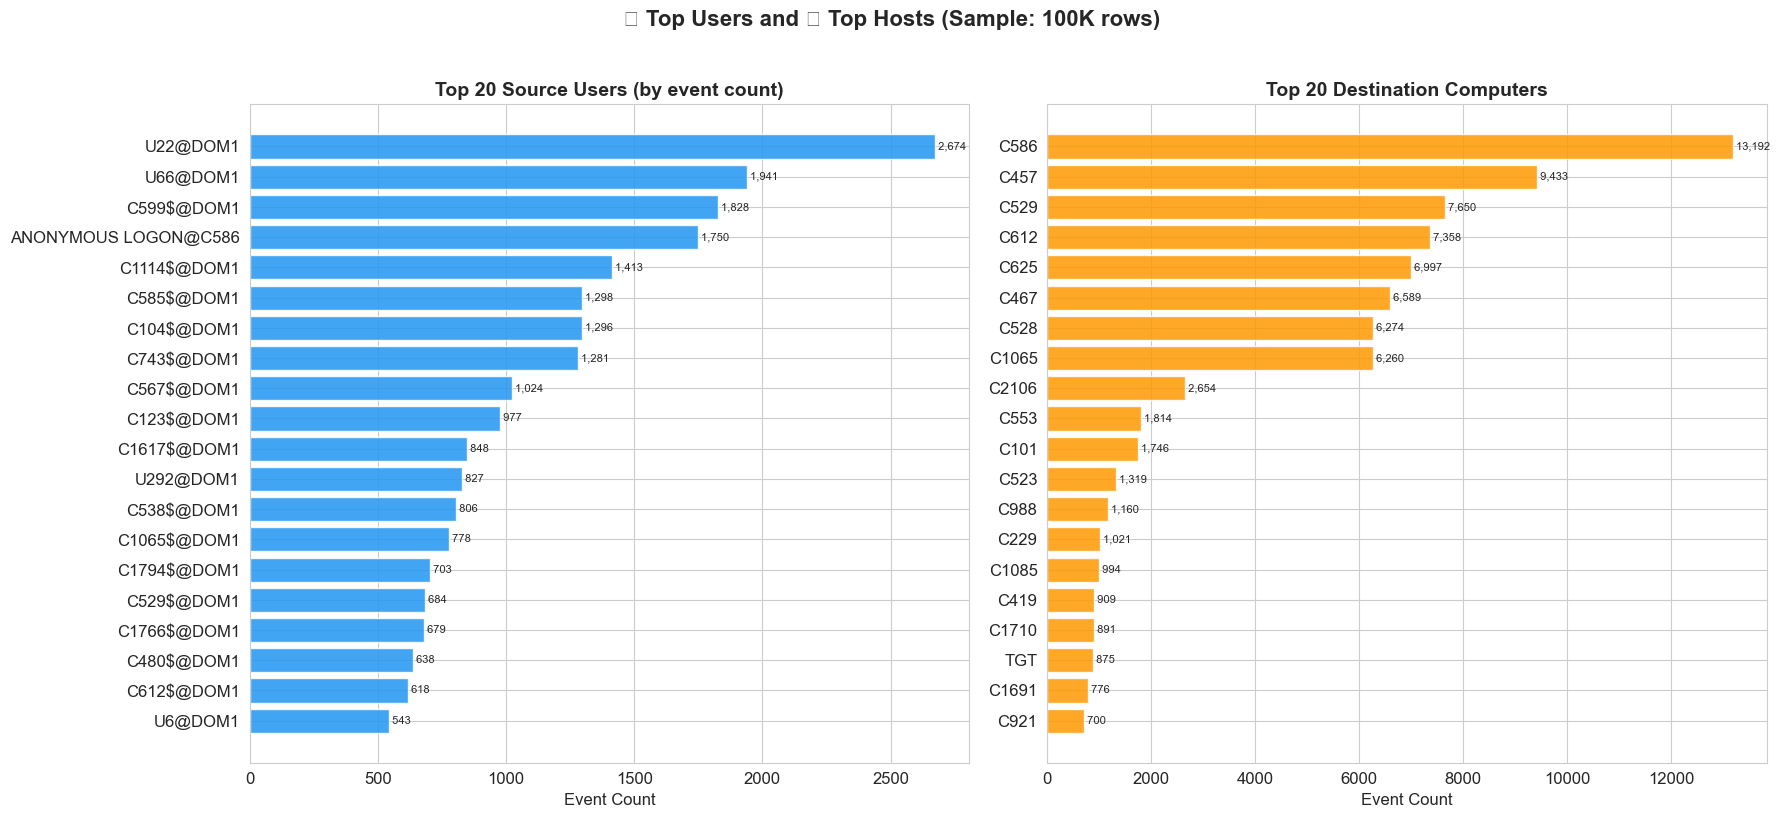


📊 Unique source users in sample: 4,923
📊 Unique dest users in sample:   6,299
📊 Unique source computers:        3,971
📊 Unique dest computers:          2,401


In [9]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 Source Users
top_users = df_sample['src_user'].value_counts().head(20)
bars1 = ax1.barh(top_users.index, top_users.values, color='#2196F3', alpha=0.85, edgecolor='white')
ax1.set_title('Top 20 Source Users (by event count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Event Count')
ax1.invert_yaxis()
for bar_item in bars1:
    width = bar_item.get_width()
    ax1.text(width, bar_item.get_y() + bar_item.get_height()/2.,
             f' {int(width):,}', ha='left', va='center', fontsize=8)

# Top 20 Destination Computers
top_hosts = df_sample['dst_computer'].value_counts().head(20)
bars2 = ax2.barh(top_hosts.index, top_hosts.values, color='#FF9800', alpha=0.85, edgecolor='white')
ax2.set_title('Top 20 Destination Computers', fontsize=14, fontweight='bold')
ax2.set_xlabel('Event Count')
ax2.invert_yaxis()
for bar_item in bars2:
    width = bar_item.get_width()
    ax2.text(width, bar_item.get_y() + bar_item.get_height()/2.,
             f' {int(width):,}', ha='left', va='center', fontsize=8)

fig.suptitle('👤 Top Users and 💻 Top Hosts (Sample: 100K rows)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quick summary stats
print(f'\n📊 Unique source users in sample: {df_sample["src_user"].nunique():,}')
print(f'📊 Unique dest users in sample:   {df_sample["dst_user"].nunique():,}')
print(f'📊 Unique source computers:        {df_sample["src_computer"].nunique():,}')
print(f'📊 Unique dest computers:          {df_sample["dst_computer"].nunique():,}')

---

## 🧱 Lesson 8: Temporal Distribution — Hourly Event Volume

### Concept: Time is everything in security

In cyber security, **when** events happen matters enormously:  
- Normal business activity happens during work hours  
- Attacks often happen at night or weekends  
- Sudden spikes = something interesting (or something broken)  

The `time` column is in **seconds since data collection started** (not a real timestamp).  
To get hours, we divide by 3600. To get days, we divide by 86400.

### Math refresher:
- 1 minute = 60 seconds  
- 1 hour = 3,600 seconds (60 × 60)  
- 1 day = 86,400 seconds (60 × 60 × 24)  

---

### ✏️ Exercise 8: Plot hourly event volume

In [ ]:
# ============================================================
# EXERCISE 8: Fill in the blanks
# ============================================================

# Blank 1: Convert seconds to hours (integer division)
# Hint: 1 hour = 3600 seconds
df_sample['hour'] = df_sample['time'] // 3600

# Blank 2: Count events per hour
# Hint: value_counts() counts occurrences, sort_index() sorts by hour number
hourly_counts = df_sample['hour'].value_counts().sort_index()

# Plot it
fig, ax = plt.subplots(figsize=(16, 5))

# Blank 3: Create a line plot of hourly event volume
ax.plot(hourly_counts.index, hourly_counts.values, color='#2196F3', linewidth=0.8, alpha=0.7)
ax.fill_between(hourly_counts.index, hourly_counts.values, alpha=0.2, color='#2196F3')

ax.set_title('Hourly Event Volume (Sample: 100K rows)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (since data collection start)')
ax.set_ylabel('Number of Events')
plt.tight_layout()
plt.show()

### 🔑 Hints for Exercise 8

<details>
<summary>Click to reveal hints</summary>

- Blank 1: `3600` — the number of seconds in one hour  
- Blank 2: `value_counts()` then `.sort_index()` — sort by hour number, not by count  
- Blank 3: `plot()` — for line charts; `ax.plot(x, y)` draws a line  

</details>

**⏸️ STOP — Try it!**

---

### ✅ Solution for Exercise 8

<details>
<summary>Click to reveal solution</summary>

```python
df_sample['hour'] = df_sample['time'] // 3600
hourly_counts = df_sample['hour'].value_counts().sort_index()
ax.plot(hourly_counts.index, hourly_counts.values, ...)
```

**What to observe:**  
- The 100K sample might cover only a few hours (since it's the first 100K rows starting from t=1)  
- You should see variation — some hours are busier (business hours)  
- The `fill_between` creates the shaded area under the line for visual clarity  

</details>

📊 Sample time range: 1s to 964s
   That's 0.3 hours = 0.01 days


C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\845906514.py:24: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


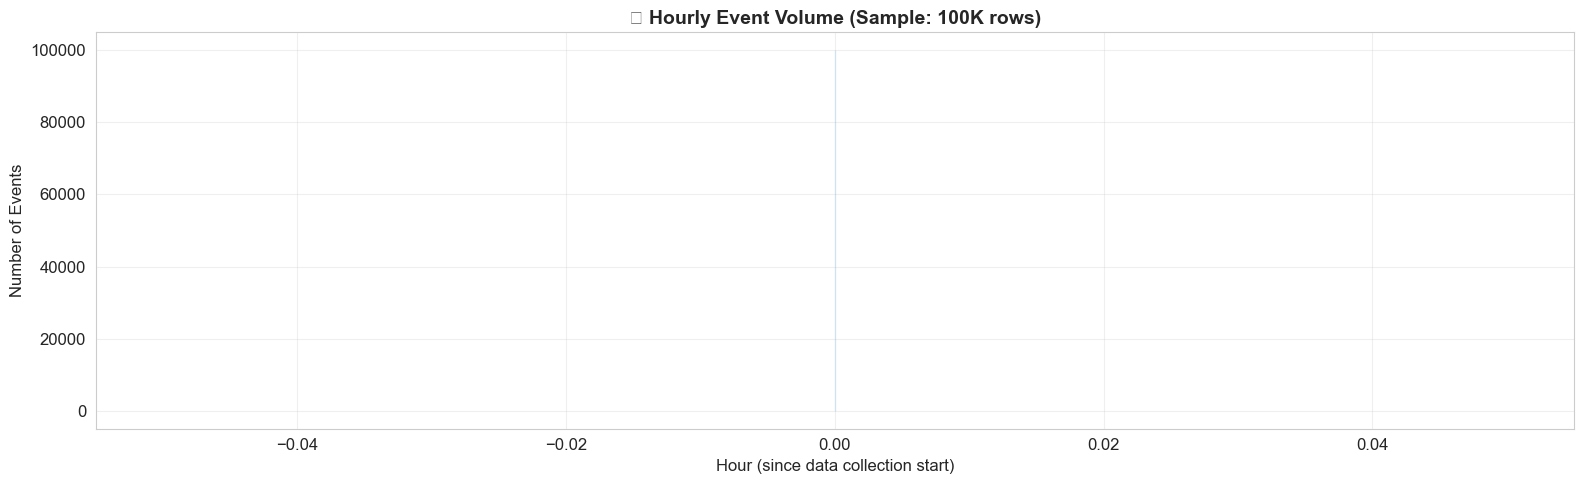

In [10]:
# ============================================================
# CORRECT VERSION — Run this cell
# ============================================================

df_sample['hour'] = df_sample['time'] // 3600
df_sample['day'] = df_sample['time'] // 86400

hourly_counts = df_sample['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(hourly_counts.index, hourly_counts.values, color='#2196F3', linewidth=0.8, alpha=0.7)
ax.fill_between(hourly_counts.index, hourly_counts.values, alpha=0.15, color='#2196F3')

ax.set_title('⏰ Hourly Event Volume (Sample: 100K rows)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (since data collection start)')
ax.set_ylabel('Number of Events')
ax.grid(alpha=0.3)

# Show what time range this sample covers
min_t, max_t = df_sample['time'].min(), df_sample['time'].max()
print(f'📊 Sample time range: {min_t:,}s to {max_t:,}s')
print(f'   That\'s {(max_t - min_t) / 3600:.1f} hours = {(max_t - min_t) / 86400:.2f} days')

plt.tight_layout()
plt.show()

---

## 🧱 Lesson 9: Full-Dataset Statistics with Chunked Reading 🔥

### Concept: The most important technique for big data

We've been working with 100K rows — that's just **0.01%** of the full dataset.  
Now we need **full-dataset statistics** without loading everything into memory.

**The trick: `chunksize` parameter in `pd.read_csv()`**

Instead of loading all 1 billion rows at once, `chunksize=N` tells pandas:  
> "Read N rows at a time. Give me each batch one by one."

```python
# This does NOT load the whole file!
# It creates an iterator that yields DataFrames of 1M rows each
chunks = pd.read_csv('big_file.csv', chunksize=1_000_000)

for chunk in chunks:
    # chunk is a DataFrame with 1M rows
    # Process it, then it gets discarded from memory
    pass
```

We'll accumulate **counters** across all chunks to get totals.

### ⚠️ This will take a while!
Processing 1 billion rows in chunks of 5 million = ~210 chunks.  
Expect this to take **10-20 minutes** depending on your disk speed.

---

### ✏️ Exercise 9: Chunked reading to get full-dataset stats

In [ ]:
# ============================================================
# EXERCISE 9: Fill in the blanks
# ============================================================

# We'll collect aggregate stats across all chunks
total_rows = 0
auth_type_counts = Counter()       # Accumulate auth_type frequencies
logon_type_counts = Counter()      # Accumulate logon_type frequencies
orientation_counts = Counter()     # Accumulate auth_orientation frequencies
success_counts = Counter()         # Accumulate success/fail frequencies
unique_src_users = set()           # Collect all unique source users
unique_dst_computers = set()       # Collect all unique destination computers
hourly_events = Counter()          # Events per hour across the full dataset

CHUNK_SIZE = 5_000_000  # 5 million rows per chunk

# Blank 1: Create the chunked reader
# Hint: Same as read_csv but with chunksize= parameter
chunks = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLUMN_NAMES,
    chunksize=CHUNK_SIZE        # How many rows per chunk?
)

print(f'Processing {TOTAL_LINES:,} rows in chunks of {CHUNK_SIZE:,}...')
print(f'Expected chunks: ~{TOTAL_LINES // CHUNK_SIZE}')
print()

for i, chunk in enumerate(chunks):
    # Blank 2: Add the number of rows in this chunk to total_rows
    total_rows += len(chunk)
    
    # Blank 3: Update the auth_type counter with this chunk's value counts
    # Hint: Counter can be updated with a dictionary. 
    #       value_counts() returns a Series, .to_dict() converts it
    auth_type_counts.update(chunk['auth_type'].value_counts().to_dict())
    logon_type_counts.update(chunk['logon_type'].value_counts().to_dict())
    orientation_counts.update(chunk['auth_orientation'].value_counts().to_dict())
    success_counts.update(chunk['success'].value_counts().to_dict())
    
    # Blank 4: Add all unique source users from this chunk to our set
    # Hint: .unique() returns an array, set.update() adds all elements
    unique_src_users.update(chunk['src_user'].unique())
    unique_dst_computers.update(chunk['dst_computer'].unique())
    
    # Compute hourly bucket and update counter
    hours = chunk['time'] // 3600
    hourly_events.update(hours.value_counts().to_dict())
    
    # Progress report every 10 chunks
    if (i + 1) % 10 == 0:
        pct = (total_rows / TOTAL_LINES) * 100
        print(f'  Chunk {i+1:>4} | {total_rows:>13,} rows processed ({pct:.1f}%)', flush=True)

print(f'\n✅ Done! Processed {total_rows:,} total rows.')

### 🔑 Hints for Exercise 9

<details>
<summary>Click to reveal hints</summary>

- Blank 1: `CHUNK_SIZE` — the variable we defined above (5,000,000)  
- Blank 2: `len(chunk)` — gets the number of rows in the chunk  
- Blank 3: `.value_counts()` then `.to_dict()` — Counter.update() accepts dicts  
- Blank 4: `.unique()` — returns an array of unique values in the column  

</details>

**⏸️ STOP — Fill in the blanks, then run it! (This will take 10-20 minutes)**

---

### ✅ Solution for Exercise 9

<details>
<summary>Click to reveal solution</summary>

```python
chunks = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES, chunksize=CHUNK_SIZE)
total_rows += len(chunk)
auth_type_counts.update(chunk['auth_type'].value_counts().to_dict())
unique_src_users.update(chunk['src_user'].unique())
```

**Why `Counter` + `update()`?**  
- A `Counter` is like a dictionary that adds values instead of replacing them  
- `Counter({'A': 5})` + `update({'A': 3, 'B': 2})` → `Counter({'A': 8, 'B': 2})`  
- This lets us accumulate counts across all chunks without keeping old data in memory  

**Why `set` for unique values?**  
- A `set` automatically deduplicates — adding the same user twice has no effect  
- `set.update()` adds all items from an iterable at once  
- At the end, `len(unique_src_users)` gives us the exact count of distinct users  

</details>

In [11]:
# ============================================================
# CORRECT VERSION — Run this cell (takes 10-20 minutes!)
# ============================================================
import time

total_rows = 0
auth_type_counts = Counter()
logon_type_counts = Counter()
orientation_counts = Counter()
success_counts = Counter()
unique_src_users = set()
unique_dst_users = set()
unique_src_computers = set()
unique_dst_computers = set()
hourly_events = Counter()
daily_events = Counter()

CHUNK_SIZE = 5_000_000

chunks = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLUMN_NAMES,
    chunksize=CHUNK_SIZE
)

print(f'🚀 Processing {TOTAL_LINES:,} rows in chunks of {CHUNK_SIZE:,}...')
print(f'   Expected chunks: ~{TOTAL_LINES // CHUNK_SIZE}')
print(f'   ⏱️  Estimated time: 10-20 minutes')
print()

start_time = time.time()

for i, chunk in enumerate(chunks):
    total_rows += len(chunk)
    
    # Accumulate categorical counts
    auth_type_counts.update(chunk['auth_type'].value_counts().to_dict())
    logon_type_counts.update(chunk['logon_type'].value_counts().to_dict())
    orientation_counts.update(chunk['auth_orientation'].value_counts().to_dict())
    success_counts.update(chunk['success'].value_counts().to_dict())
    
    # Accumulate unique entities
    unique_src_users.update(chunk['src_user'].unique())
    unique_dst_users.update(chunk['dst_user'].unique())
    unique_src_computers.update(chunk['src_computer'].unique())
    unique_dst_computers.update(chunk['dst_computer'].unique())
    
    # Temporal buckets
    hourly_events.update((chunk['time'] // 3600).value_counts().to_dict())
    daily_events.update((chunk['time'] // 86400).value_counts().to_dict())
    
    # Progress every 10 chunks
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_time
        pct = (total_rows / TOTAL_LINES) * 100
        rows_per_sec = total_rows / elapsed
        remaining = (TOTAL_LINES - total_rows) / rows_per_sec
        print(f'  Chunk {i+1:>4} | {total_rows:>13,} rows ({pct:5.1f}%) | '
              f'{elapsed:.0f}s elapsed | ~{remaining:.0f}s remaining', flush=True)

elapsed = time.time() - start_time
print(f'\n✅ Done! Processed {total_rows:,} rows in {elapsed:.0f} seconds ({elapsed/60:.1f} minutes)')

🚀 Processing 1,051,430,459 rows in chunks of 5,000,000...
   Expected chunks: ~210
   ⏱️  Estimated time: 10-20 minutes

  Chunk   10 |    50,000,000 rows (  4.8%) | 96s elapsed | ~1921s remaining
  Chunk   20 |   100,000,000 rows (  9.5%) | 191s elapsed | ~1820s remaining
  Chunk   30 |   150,000,000 rows ( 14.3%) | 289s elapsed | ~1739s remaining
  Chunk   40 |   200,000,000 rows ( 19.0%) | 386s elapsed | ~1644s remaining
  Chunk   50 |   250,000,000 rows ( 23.8%) | 485s elapsed | ~1554s remaining
  Chunk   60 |   300,000,000 rows ( 28.5%) | 584s elapsed | ~1462s remaining
  Chunk   70 |   350,000,000 rows ( 33.3%) | 683s elapsed | ~1368s remaining
  Chunk   80 |   400,000,000 rows ( 38.0%) | 782s elapsed | ~1274s remaining
  Chunk   90 |   450,000,000 rows ( 42.8%) | 880s elapsed | ~1176s remaining
  Chunk  100 |   500,000,000 rows ( 47.6%) | 980s elapsed | ~1080s remaining
  Chunk  110 |   550,000,000 rows ( 52.3%) | 1078s elapsed | ~983s remaining
  Chunk  120 |   600,000,000 rows

---

## 🧱 Lesson 10: Full-Dataset Summary Dashboard

### Concept: Presenting your findings

Now that we've processed ALL the data, let's display a comprehensive summary.  
This is what you'd put in a report or show a stakeholder.  

No exercise here — just run it and study the output!

---

In [12]:
# ============================================================
# FULL-DATASET SUMMARY — Run this cell
# ============================================================

print('╔══════════════════════════════════════════════════════════╗')
print('║        LANL CYBER1 AUTH DATASET — FULL SUMMARY         ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Total Events:        {total_rows:>28,}  ║')
print(f'║  File Size:           {file_size_gb:>25.2f} GB  ║')
print(f'║  Time Span:           {5_011_199 / 86400:>22.1f} days  ║')
print(f'║  Unique Source Users:  {len(unique_src_users):>27,}  ║')
print(f'║  Unique Dest Users:    {len(unique_dst_users):>27,}  ║')
print(f'║  Unique Src Computers: {len(unique_src_computers):>27,}  ║')
print(f'║  Unique Dst Computers: {len(unique_dst_computers):>27,}  ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  AUTH TYPE DISTRIBUTION                                 ║')
print('╠══════════════════════════════════════════════════════════╣')
for k, v in auth_type_counts.most_common():
    pct = (v / total_rows) * 100
    print(f'║  {k:20s} {v:>15,}  ({pct:5.1f}%)     ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  LOGON TYPE DISTRIBUTION                                ║')
print('╠══════════════════════════════════════════════════════════╣')
for k, v in logon_type_counts.most_common():
    pct = (v / total_rows) * 100
    print(f'║  {k:20s} {v:>15,}  ({pct:5.1f}%)     ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  AUTH ORIENTATION DISTRIBUTION                          ║')
print('╠══════════════════════════════════════════════════════════╣')
for k, v in orientation_counts.most_common():
    pct = (v / total_rows) * 100
    print(f'║  {k:20s} {v:>15,}  ({pct:5.1f}%)     ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  SUCCESS/FAILURE                                        ║')
print('╠══════════════════════════════════════════════════════════╣')
for k, v in success_counts.most_common():
    pct = (v / total_rows) * 100
    print(f'║  {k:20s} {v:>15,}  ({pct:5.1f}%)     ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║        LANL CYBER1 AUTH DATASET — FULL SUMMARY         ║
╠══════════════════════════════════════════════════════════╣
║  Total Events:                       1,051,430,459  ║
║  File Size:                               68.37 GB  ║
║  Time Span:                             58.0 days  ║
║  Unique Source Users:                       80,553  ║
║  Unique Dest Users:                         98,563  ║
║  Unique Src Computers:                      16,230  ║
║  Unique Dst Computers:                      15,895  ║
╠══════════════════════════════════════════════════════════╣
║  AUTH TYPE DISTRIBUTION                                 ║
╠══════════════════════════════════════════════════════════╣
║  ?                        583,350,819  ( 55.5%)     ║
║  Kerberos                 362,830,725  ( 34.5%)     ║
║  Negotiate                 55,047,638  (  5.2%)     ║
║  NTLM                      49,341,300  (  4.7%)     ║
║  MICROSOFT_AUTHENTIC

---

## 🧱 Lesson 11: Temporal Distribution — Full 58 Days

### Concept: Daily event volume across the full dataset

Now we can plot the **daily event volume** across all 58 days.  
This reveals patterns like:  
- Weekday vs weekend activity (authentication drops on weekends)  
- Any anomalous spikes or dips  
- Overall trend (stable? growing? declining?)  

No exercise here — just run it and study the patterns.

C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\484308341.py:34: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\484308341.py:34: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\484308341.py:34: UserWarning: Glyph 128336 (\N{CLOCK FACE ONE OCLOCK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) Arial.
  fig.canvas.print_f

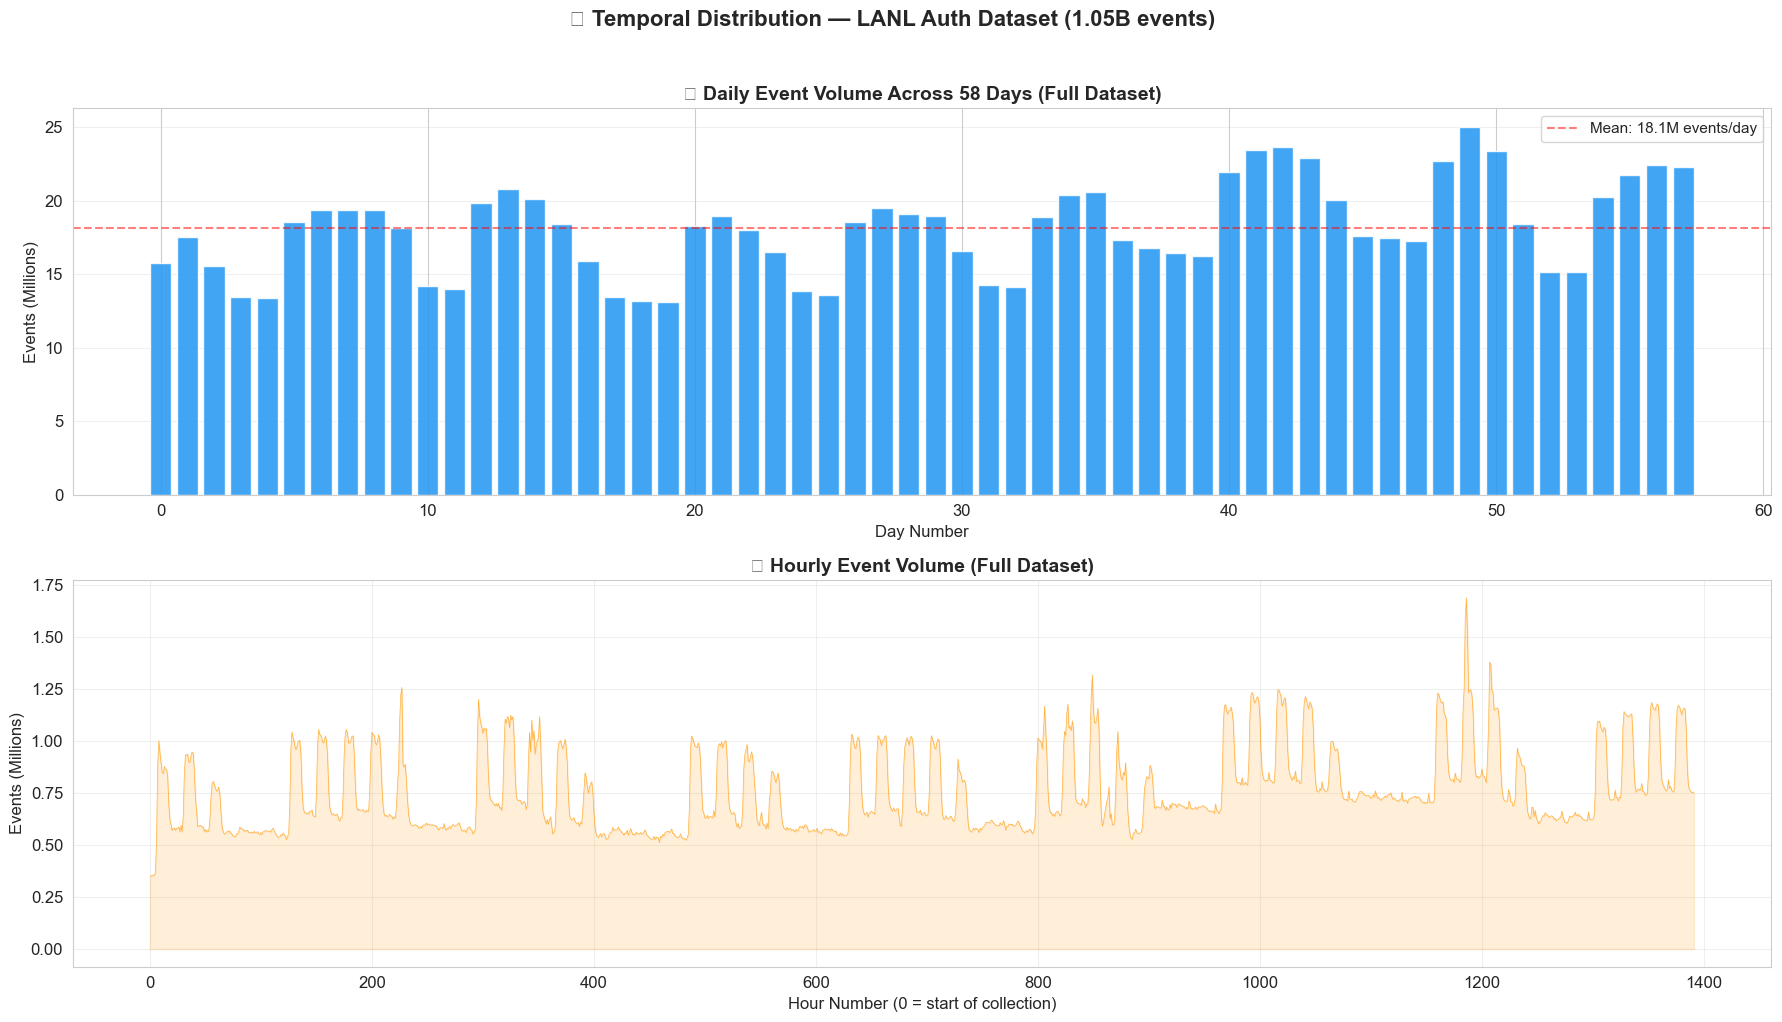


📊 Average events per day: 18,128,111
📊 Busiest day (day 49): 25,025,364 events
📊 Quietest day (day 19): 13,138,831 events


In [13]:
# ============================================================
# FULL 58-DAY TEMPORAL DISTRIBUTION — Run this cell
# ============================================================

# Convert Counter to sorted Series for plotting
daily_series = pd.Series(daily_events).sort_index()
hourly_series = pd.Series(hourly_events).sort_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))

# --- Daily Event Volume ---
ax1.bar(daily_series.index, daily_series.values / 1e6,
        color='#2196F3', alpha=0.85, edgecolor='white', width=0.8)
ax1.set_title('📅 Daily Event Volume Across 58 Days (Full Dataset)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Day Number')
ax1.set_ylabel('Events (Millions)')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=daily_series.mean() / 1e6, color='red', linestyle='--', alpha=0.5,
            label=f'Mean: {daily_series.mean()/1e6:.1f}M events/day')
ax1.legend(fontsize=11)

# --- Hourly Event Volume ---
ax2.plot(hourly_series.index, hourly_series.values / 1e6,
         color='#FF9800', linewidth=0.5, alpha=0.7)
ax2.fill_between(hourly_series.index, hourly_series.values / 1e6,
                 alpha=0.15, color='#FF9800')
ax2.set_title('⏰ Hourly Event Volume (Full Dataset)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour Number (0 = start of collection)')
ax2.set_ylabel('Events (Millions)')
ax2.grid(alpha=0.3)

fig.suptitle('🕐 Temporal Distribution — LANL Auth Dataset (1.05B events)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 Average events per day: {daily_series.mean():,.0f}')
print(f'📊 Busiest day (day {daily_series.idxmax()}): {daily_series.max():,.0f} events')
print(f'📊 Quietest day (day {daily_series.idxmin()}): {daily_series.min():,.0f} events')

---

## 🧱 Lesson 12: Full-Dataset Event Type Distributions

Let's re-plot the event type distributions using the **full dataset counts** (not just the 100K sample).

C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\1310454248.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


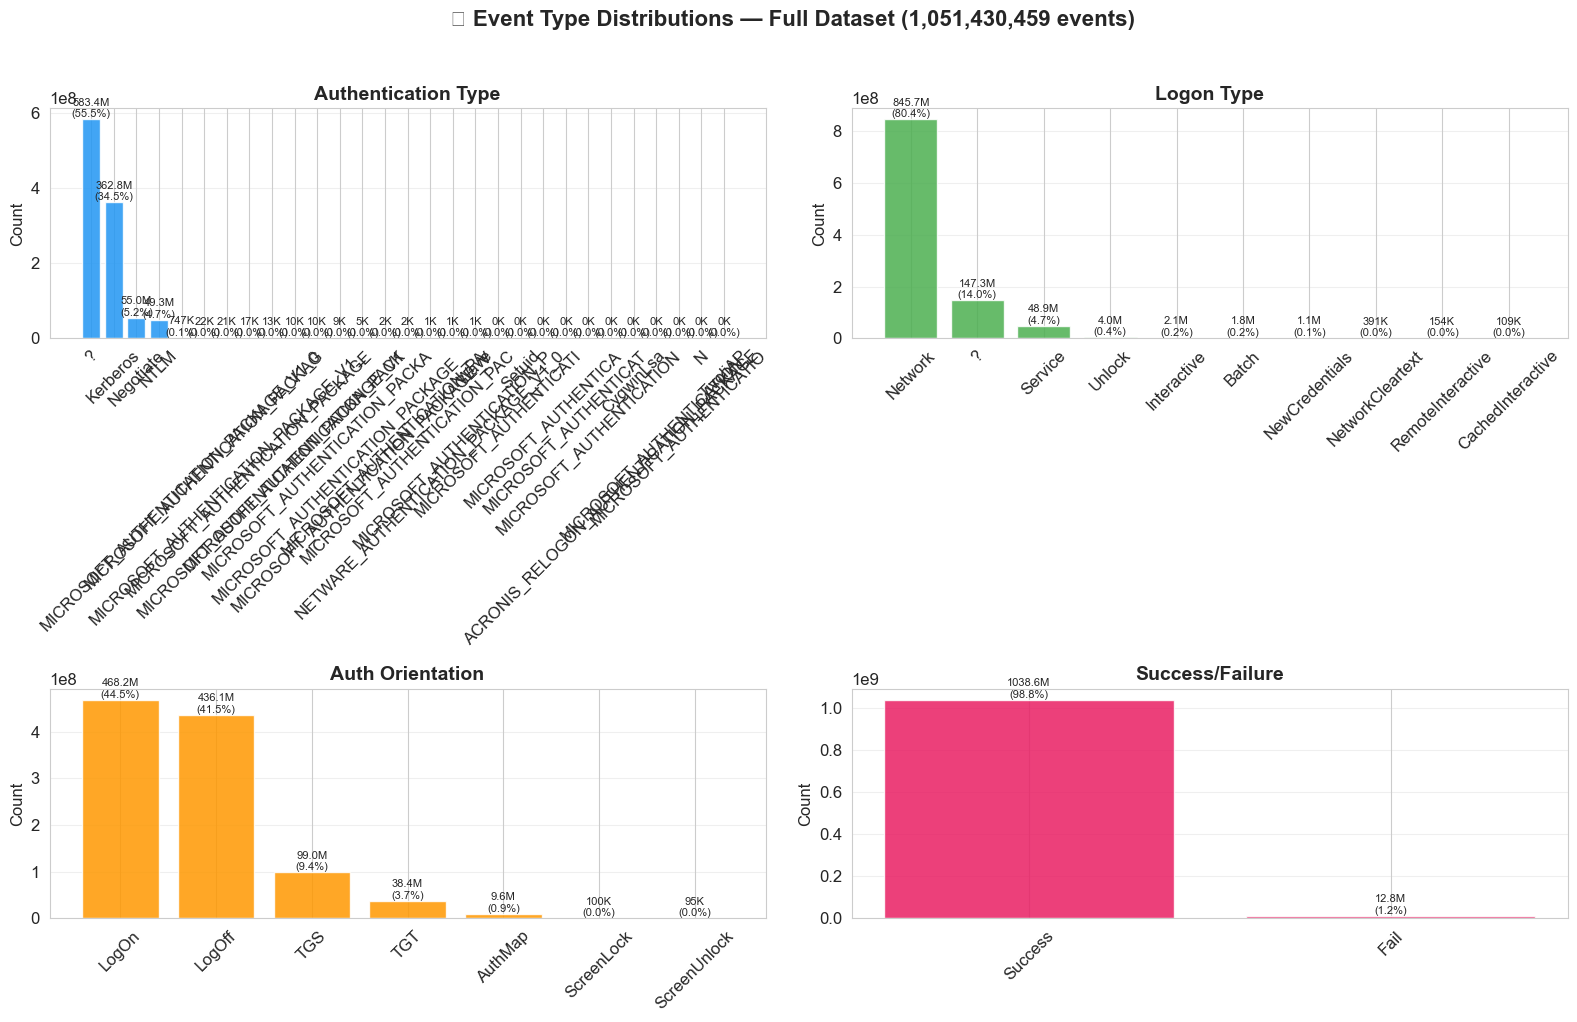

In [14]:
# ============================================================
# FULL-DATASET EVENT TYPE DISTRIBUTIONS — Run this cell
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

counters = [auth_type_counts, logon_type_counts, orientation_counts, success_counts]
titles = ['Authentication Type', 'Logon Type', 'Auth Orientation', 'Success/Failure']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for idx, (counter, title, color) in enumerate(zip(counters, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    
    # Sort by count descending
    labels = [k for k, v in counter.most_common()]
    values = [v for k, v in counter.most_common()]
    
    bars = ax.bar(labels, values, color=color, alpha=0.85, edgecolor='white')
    
    # Add labels
    for bar_item in bars:
        height = bar_item.get_height()
        pct = height / total_rows * 100
        label = f'{height/1e6:.1f}M' if height > 1e6 else f'{height/1e3:.0f}K'
        ax.text(bar_item.get_x() + bar_item.get_width()/2., height,
                f'{label}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'📊 Event Type Distributions — Full Dataset ({total_rows:,} events)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 🧱 Lesson 13: Red Team Events — The Ground Truth 🔴

### Concept: What are red team events?

The LANL dataset includes a separate file called `redteam.txt` with **749 known attack events**.  
These are authentication events performed by the security team simulating an attacker.  

The red team file has a simpler format:  
`timestamp, source_user@domain, source_computer, destination_computer`

**Why this matters:**  
- These 749 events are our **ground truth** labels for anomaly detection  
- They tell us exactly which user, at what time, performed a malicious authentication  
- Out of 1 billion+ events, only 749 are attacks — that's **0.0000071%**  
- This extreme imbalance is realistic and makes detection very challenging  

### Local-first file handling (your current setup)
In this project, we expect decompressed files in `data/lanl/` (including `auth.txt` and `redteam.txt`).  
If `redteam.txt` is missing, we optionally fall back to `redteam.txt.gz` or provide a download hint.

---

In [15]:
# ============================================================
# RED TEAM DATA — local-first loader (decompressed file preferred)
# ============================================================

REDTEAM_PATH = os.path.join(os.path.dirname(DATA_PATH), 'redteam.txt')

# We support either data/lanl/redteam.txt.gz or data/raw/redteam.txt.gz
candidate_gz_paths = [
    os.path.join(os.path.dirname(DATA_PATH), 'redteam.txt.gz'),
    os.path.join(os.path.dirname(os.path.dirname(DATA_PATH)), 'raw', 'redteam.txt.gz'),
]
REDTEAM_GZ_PATH = next((p for p in candidate_gz_paths if os.path.exists(p)), None)

if os.path.exists(REDTEAM_PATH):
    print(f'✅ Using local decompressed red team file: {REDTEAM_PATH}')
    df_redteam = pd.read_csv(
        REDTEAM_PATH,
        header=None,
        names=['time', 'src_user', 'src_computer', 'dst_computer']
    )
    print(f'   Red team events loaded: {len(df_redteam):,}')

elif REDTEAM_GZ_PATH is not None:
    import gzip
    print(f'📦 Found compressed red team file: {REDTEAM_GZ_PATH}')
    print('   Decompressing to data/lanl/redteam.txt ...')

    with gzip.open(REDTEAM_GZ_PATH, 'rt') as f_in, open(REDTEAM_PATH, 'w') as f_out:
        f_out.write(f_in.read())

    df_redteam = pd.read_csv(
        REDTEAM_PATH,
        header=None,
        names=['time', 'src_user', 'src_computer', 'dst_computer']
    )
    print(f'   ✅ Red team events loaded: {len(df_redteam):,}')

else:
    print('⚠️ redteam.txt not found in data/lanl/.')
    print(f'   Expected path: {REDTEAM_PATH}')
    print('   Optional: place redteam.txt.gz in data/lanl/ or data/raw/.')
    print('   Download source: https://csr.lanl.gov/data/cyber1/')
    print()
    print('   Continuing without red team labels for now...')
    df_redteam = None

✅ Using local decompressed red team file: c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\data\lanl\redteam.txt
   Red team events loaded: 749


In [16]:
# ============================================================
# RED TEAM ANALYSIS — Run this cell (only works if redteam.txt exists)
# ============================================================

if df_redteam is not None:
    print('🔴 RED TEAM EVENT ANALYSIS')
    print('='*55)
    print(f'Total red team events:     {len(df_redteam):,}')
    print(f'Total auth events:         {total_rows:,}')
    print(f'Attack ratio:              {len(df_redteam)/total_rows*100:.7f}%')
    print(f'\nRed team time range:       {df_redteam["time"].min():,}s to {df_redteam["time"].max():,}s')
    print(f'  = Day {df_redteam["time"].min()//86400} to Day {df_redteam["time"].max()//86400}')
    print(f'\nUnique attacking users:    {df_redteam["src_user"].nunique()}')
    print(f'Unique target computers:   {df_redteam["dst_computer"].nunique()}')
    
    print(f'\n📊 Attack users:')
    print(df_redteam['src_user'].value_counts())
    
    print(f'\n📊 First 5 red team events:')
    print(df_redteam.head())
    print(f'\n📊 Last 5 red team events:')
    print(df_redteam.tail())
else:
    print('⏭️ Skipping red team analysis (file not available)')

🔴 RED TEAM EVENT ANALYSIS
Total red team events:     749
Total auth events:         1,051,430,459
Attack ratio:              0.0000712%

Red team time range:       150,885s to 2,557,047s
  = Day 1 to Day 29

Unique attacking users:    104
Unique target computers:   301

📊 Attack users:
src_user
U66@DOM1       118
U3005@DOM1      36
U737@DOM1       32
U1653@DOM1      31
U293@DOM1       31
              ... 
U8840@DOM1       1
U1306@DOM1       1
U3764@DOM1       1
U1467@C3597      1
U3406@DOM1       1
Name: count, Length: 104, dtype: int64

📊 First 5 red team events:
     time    src_user src_computer dst_computer
0  150885   U620@DOM1       C17693        C1003
1  151036   U748@DOM1       C17693         C305
2  151648   U748@DOM1       C17693         C728
3  151993  U6115@DOM1       C17693        C1173
4  153792   U636@DOM1       C17693         C294

📊 Last 5 red team events:
        time   src_user src_computer dst_computer
744  2552687  U655@DOM1       C17693         C828
745  2552687 

C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\2691445552.py:37: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark Christian Anub\AppData\Local\Temp\ipykernel_59436\2691445552.py:37: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Mark Christian Anub\Desktop\newproject\argus-log-intelligence-platform\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


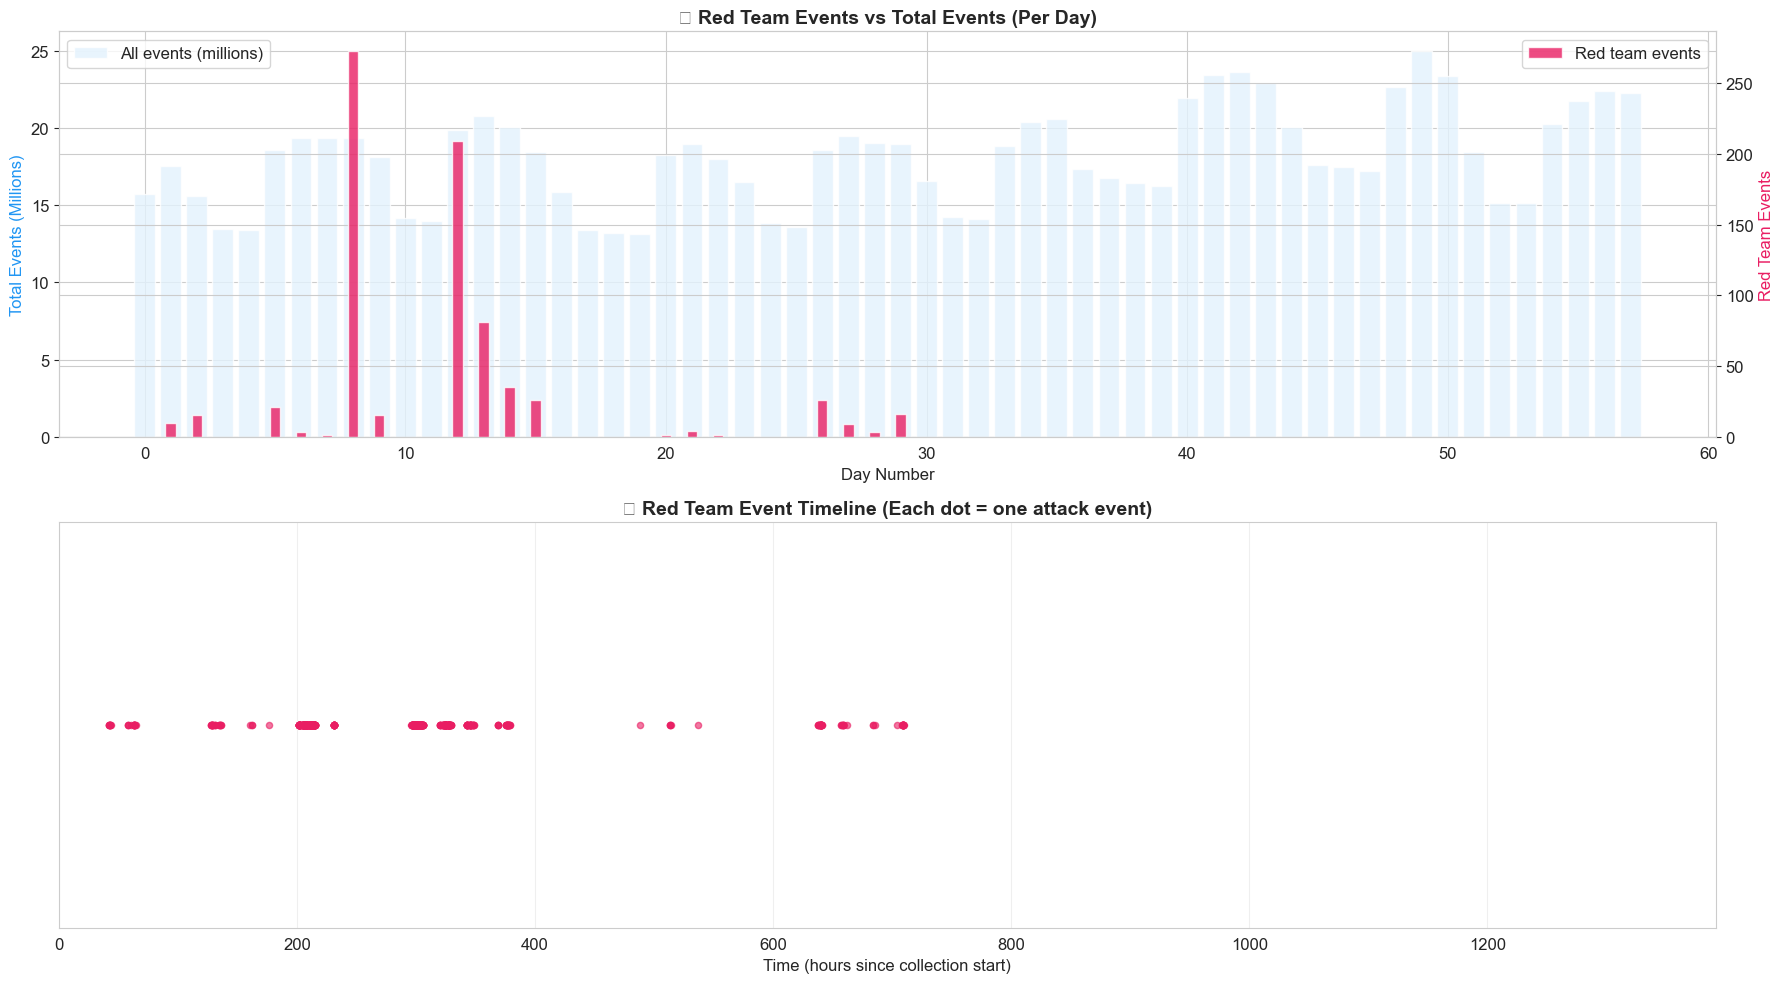

In [17]:
# ============================================================
# RED TEAM TEMPORAL DISTRIBUTION — Run this cell
# ============================================================

if df_redteam is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))
    
    # --- Red team events per day ---
    rt_daily = (df_redteam['time'] // 86400).value_counts().sort_index()
    
    # Background: all events per day (in millions)
    ax1.bar(daily_series.index, daily_series.values / 1e6,
            color='#E3F2FD', alpha=0.8, width=0.8, label='All events (millions)')
    
    # Overlay: red team events per day (on secondary y-axis)
    ax1_twin = ax1.twinx()
    ax1_twin.bar(rt_daily.index, rt_daily.values,
                 color='#E91E63', alpha=0.8, width=0.4, label='Red team events')
    
    ax1.set_title('📅 Red Team Events vs Total Events (Per Day)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Day Number')
    ax1.set_ylabel('Total Events (Millions)', color='#2196F3')
    ax1_twin.set_ylabel('Red Team Events', color='#E91E63')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')
    
    # --- Red team events timeline ---
    rt_hours = df_redteam['time'] / 3600  # Convert to hours for scatter
    ax2.scatter(rt_hours, [1]*len(rt_hours), color='#E91E63', s=20, alpha=0.6)
    ax2.set_title('🔴 Red Team Event Timeline (Each dot = one attack event)',
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Time (hours since collection start)')
    ax2.set_yticks([])
    ax2.set_xlim(0, 5_011_199 / 3600)
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print('⏭️ Skipping (no red team file)')

---

## 🧱 Lesson 14: Side-by-Side — Red Team vs Normal Events

### Concept: What makes attack events look different?

To build a good anomaly detector, you need to understand:  
1. What do normal events look like for an attacking user?  
2. What does their attack event look like?  
3. Can you spot the difference?  

We'll load events for specific red team users and compare their normal vs malicious activity.

In [18]:
# ============================================================
# RED TEAM vs NORMAL — Side by Side (takes a few minutes)
# ============================================================

if df_redteam is not None:
    # Get the list of red team user names
    rt_users = df_redteam['src_user'].unique().tolist()
    print(f'Red team users: {rt_users}')
    
    # Get the timestamps of red team events
    rt_times = set(df_redteam['time'].unique())
    
    # Load events for red team users from the first portion of the file
    # We'll scan chunks looking for these users
    print(f'\nScanning for events by red team users...')
    
    rt_user_events = []
    chunks = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES, chunksize=5_000_000)
    
    for i, chunk in enumerate(chunks):
        # Filter to rows where src_user is a red team user
        mask = chunk['src_user'].isin(rt_users)
        if mask.any():
            rt_user_events.append(chunk[mask].copy())
        
        # Stop after processing a reasonable amount
        if (i + 1) * 5_000_000 > 200_000_000:  # First 200M rows
            break
        if (i + 1) % 10 == 0:
            found = sum(len(df) for df in rt_user_events)
            print(f'  Chunk {i+1} — found {found:,} events by red team users so far', flush=True)
    
    if rt_user_events:
        df_rt_users = pd.concat(rt_user_events, ignore_index=True)
        print(f'\n✅ Found {len(df_rt_users):,} events from red team users')
        
        # Mark which are actual attack events (time matches red team file)
        df_rt_users['is_attack'] = df_rt_users['time'].isin(rt_times)
        
        print(f'   Attack events found: {df_rt_users["is_attack"].sum()}')
        print(f'   Normal events found: {(~df_rt_users["is_attack"]).sum()}')
    else:
        print('⚠️ No events found for red team users in first 200M rows')
        df_rt_users = None
else:
    print('⏭️ Skipping (no red team file)')
    df_rt_users = None

Red team users: ['U620@DOM1', 'U748@DOM1', 'U6115@DOM1', 'U636@DOM1', 'U1723@DOM1', 'U737@DOM1', 'U825@DOM1', 'U1653@DOM1', 'U293@DOM1', 'U8946@DOM1', 'U10379@C3521', 'U8601@DOM1', 'U212@DOM1', 'U4978@DOM1', 'U3905@DOM1', 'U995@DOM1', 'U288@DOM1', 'U2837@DOM1', 'U349@DOM1', 'U250@DOM1', 'U1600@DOM1', 'U4353@DOM1', 'U4856@DOM1', 'U5087@DOM1', 'U9763@DOM1', 'U795@DOM1', 'U9947@DOM1', 'U882@DOM1', 'U8777@C583', 'U1450@DOM1', 'U8777@C1500', 'U8777@C3388', 'U374@DOM1', 'U2575@DOM1', 'U3718@DOM1', 'U342@DOM1', 'U6572@DOM1', 'U162@DOM1', 'U314@DOM1', 'U642@DOM1', 'U3635@DOM1', 'U1480@DOM1', 'U66@DOM1', 'U1164@DOM1', 'U7394@DOM1', 'U1048@DOM1', 'U5254@DOM1', 'U7375@DOM1', 'U4448@DOM1', 'U218@DOM1', 'U4112@DOM1', 'U12@DOM1', 'U13@DOM1', 'U1289@DOM1', 'U3277@C2519', 'U1519@DOM1', 'U7761@C2519', 'U7004@C2519', 'U207@DOM1', 'U1145@DOM1', 'U453@DOM1', 'U9263@DOM1', 'U20@DOM1', 'U7507@DOM1', 'U415@DOM1', 'U1569@DOM1', 'U1581@DOM1', 'U6764@DOM1', 'U1789@DOM1', 'U6691@DOM1', 'U78@DOM1', 'U3005@DOM1', 

In [19]:
# ============================================================
# SIDE-BY-SIDE COMPARISON — Run this cell
# ============================================================

if df_rt_users is not None and df_rt_users['is_attack'].sum() > 0:
    # Pick a user with both attack and normal events
    attack_events = df_rt_users[df_rt_users['is_attack']]
    normal_events = df_rt_users[~df_rt_users['is_attack']]
    
    print('='*80)
    print('🔴 SAMPLE ATTACK EVENTS (Red Team)')
    print('='*80)
    print(attack_events.head(5).to_string(index=False))
    
    print(f'\n{"="*80}')
    print('🟢 SAMPLE NORMAL EVENTS (Same Users)')
    print('='*80)
    # Get normal events from the same users near the same time
    for user in attack_events['src_user'].unique()[:2]:
        user_normal = normal_events[normal_events['src_user'] == user]
        if len(user_normal) > 0:
            print(f'\n  User: {user}')
            print(user_normal.head(5).to_string(index=False))
    
    print(f'\n{"="*80}')
    print('💡 KEY DIFFERENCES TO OBSERVE')
    print('='*80)
    print('  Compare the columns between attack and normal events:')
    print('  - dst_computer: Does the attacker target different machines?')
    print('  - auth_type: Does the protocol change during attacks?')
    print('  - logon_type: Does the access method change?')
    print('  - time: Do attacks happen at unusual times?')
elif df_redteam is not None:
    print('⚠️ No attack events found in the scanned portion.')
    print('   Red team events may occur later in the dataset.')
    print(f'   Earliest red team event: second {df_redteam["time"].min():,} '
          f'(day {df_redteam["time"].min()//86400})')
else:
    print('⏭️ Skipping (no red team file)')

🔴 SAMPLE ATTACK EVENTS (Red Team)
  time  src_user  dst_user src_computer dst_computer auth_type logon_type auth_orientation success  is_attack
150885 U453@DOM1 U453@DOM1        C1015        C1015         ?    Network           LogOff Success       True
150885 U620@DOM1 U620@DOM1       C17693        C1003      NTLM    Network            LogOn Success       True
150885  U66@DOM1  U66@DOM1        C2358        C2358         ?    Network           LogOff Success       True
150885  U66@DOM1  U66@DOM1        C2358        C2358  Kerberos    Network            LogOn Success       True
151036  U12@DOM1  U12@DOM1         C368         C368         ?    Network           LogOff Success       True

🟢 SAMPLE NORMAL EVENTS (Same Users)

  User: U453@DOM1
 time  src_user  dst_user src_computer dst_computer auth_type logon_type auth_orientation success  is_attack
 1883 U453@DOM1 U453@DOM1        C1065        C1065         ?    Network           LogOff Success      False
 1883 U453@DOM1 U453@DOM1       

---

## 📋 Lesson 15: EDA Summary & Key Findings

### What we learned about the LANL dataset

In [20]:
# ============================================================
# FINAL SUMMARY — Run this cell
# ============================================================

print('''
╔══════════════════════════════════════════════════════════════════╗
║            📊 EDA SUMMARY — LANL CYBER1 AUTH DATASET            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  ────────────────                                                ║''')
print(f'║  • Total events:          {total_rows:>15,}                 ║')
print(f'║  • File size:             {file_size_gb:>12.2f} GB                    ║')
print(f'║  • Time span:             {5_011_199/86400:>12.1f} days                  ║')
print(f'║  • Unique source users:   {len(unique_src_users):>15,}                 ║')
print(f'║  • Unique dest users:     {len(unique_dst_users):>15,}                 ║')
print(f'║  • Unique src computers:  {len(unique_src_computers):>15,}                 ║')
print(f'║  • Unique dst computers:  {len(unique_dst_computers):>15,}                 ║')
if df_redteam is not None:
    print(f'║  • Red team events:       {len(df_redteam):>15,}                 ║')
    print(f'║  • Attack ratio:          {len(df_redteam)/total_rows*100:>14.7f}%                 ║')
print('''║                                                                  ║
║  KEY FINDINGS                                                    ║
║  ────────────                                                    ║
║  1. The dataset is MASSIVE — chunked processing is mandatory     ║
║  2. "?" auth type dominates — many events lack protocol info     ║
║  3. Network logons are the most common type                      ║
║  4. Success vastly outnumbers Failure                            ║
║  5. Red team events are extremely rare (needle in a haystack)    ║
║  6. Machine accounts generate the most traffic                   ║
║  7. Clear daily patterns exist (business hours vs off-hours)     ║
║                                                                  ║
║  DESIGN IMPLICATIONS FOR ARGUS                                   ║
║  ──────────────────────────────                                   ║
║  • Parser must handle streaming — can't load full file in RAM    ║
║  • Need to separate machine vs human accounts                    ║
║  • Anomaly detection must handle extreme class imbalance         ║
║  • Temporal features (hour-of-day, day-of-week) will be useful   ║
║  • The "?" values need a strategy (drop, impute, or keep)        ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
''')
print('🎉 EDA Complete! You now understand your dataset.')
print('👉 Next step: Build the data parser (Step P1.2)')


╔══════════════════════════════════════════════════════════════════╗
║            📊 EDA SUMMARY — LANL CYBER1 AUTH DATASET            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET OVERVIEW                                                ║
║  ────────────────                                                ║
║  • Total events:            1,051,430,459                 ║
║  • File size:                    68.37 GB                    ║
║  • Time span:                     58.0 days                  ║
║  • Unique source users:            80,553                 ║
║  • Unique dest users:              98,563                 ║
║  • Unique src computers:           16,230                 ║
║  • Unique dst computers:           15,895                 ║
║  • Red team events:                   749                 ║
║  • Attack ratio:               0.0000712%                 ║
║                      

---

## 🎓 What You Learned in This Notebook

| # | Skill | Why It Matters |
|---|-------|---------------|
| 1 | Standard imports (`pd`, `plt`, `sns`) | Every data science project starts here |
| 2 | `pd.read_csv()` with `header`, `names`, `nrows` | Loading data correctly |
| 3 | `.shape`, `.dtypes`, `.isnull()`, `.describe()`, `.nunique()` | The 5-question inspection |
| 4 | `.value_counts()` | Understanding categorical distributions |
| 5 | `plt.subplots()` + bar/line charts | Visualizing distributions |
| 6 | EventID-equivalent signatures | Getting top-20 event patterns in LANL auth logs |
| 7 | **Chunked reading** with `chunksize=` | Processing files larger than RAM |
| 8 | `Counter` + `set` for aggregation | Accumulating stats across chunks |
| 9 | Red team event analysis | Understanding ground truth in security data |

---

*Notebook created for the ARGUS Log Intelligence Platform — Step P1.1*